<a href="https://colab.research.google.com/github/FaizunKarim/DTS-Data-Scientist-Supervisor/blob/main/California_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
cols_to_clean = ['AveRooms', 'AveBedrms', 'AveOccup']

Q1 = df[cols_to_clean].quantile(0.25)
Q3 = df[cols_to_clean].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[~((df[cols_to_clean] < lower_bound) | (df[cols_to_clean] > upper_bound)).any(axis=1)].copy()

print(f'Original shape: {df.shape}')
print(f'Cleaned shape: {df_cleaned.shape}')
print('\n--- Statistics After Outlier Removal ---')
print(df_cleaned[cols_to_clean].describe())

print(f'\nNumber of duplicate rows: {df_cleaned.duplicated().sum()}')

Original shape: (20640, 9)
Cleaned shape: (18405, 9)

--- Statistics After Outlier Removal ---
           AveRooms     AveBedrms      AveOccup
count  18405.000000  18405.000000  18405.000000
mean       5.238143      1.047917      2.856685
std        1.124326      0.065921      0.626045
min        2.032738      0.866013      1.161290
25%        4.448980      1.004149      2.431520
50%        5.197861      1.044316      2.810166
75%        5.958763      1.088435      3.236301
max        8.469738      1.239521      4.560748

Number of duplicate rows: 0


In [53]:
from sklearn.preprocessing import StandardScaler
df_cleaned['BedroomsPerRoom'] = df_cleaned['AveBedrms'] / df_cleaned['AveRooms']
features_to_scale = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'BedroomsPerRoom']
scaler = StandardScaler()
df_transformed = df_cleaned.copy()
df_transformed[features_to_scale] = scaler.fit_transform(df_cleaned[features_to_scale])
print('--- Transformed DataFrame Head ---')
print(df_transformed.head())
print('\n--- Transformed Descriptive Statistics ---')
print(df_transformed[features_to_scale].describe().loc[['mean', 'std', 'min', 'max']])

--- Transformed DataFrame Head ---
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.469497  0.967120  1.552958  -0.365717   -1.048740 -0.481017  1.066368   
1  2.456219 -0.634003  0.889441  -1.153479    0.877563 -1.192988  1.056919   
2  1.873752  1.847737  2.712803   0.387272   -0.887520 -0.086938  1.052194   
3  0.973105  1.847737  0.515175   0.381402   -0.830073 -0.493173  1.052194   
4 -0.029419  1.847737  0.928324   0.503091   -0.823588 -1.078576  1.052194   

   Longitude  MedHouseVal  BedroomsPerRoom  
0  -1.318799        4.526        -1.212859  
1  -1.313776        3.585        -1.037727  
2  -1.323823        3.521        -1.537696  
3  -1.328846        3.413        -0.492457  
4  -1.328846        3.422        -0.727645  

--- Transformed Descriptive Statistics ---
            MedInc      HouseAge      AveRooms     AveBedrms    Population  \
mean  3.088477e-17  9.265431e-17 -1.729547e-16 -6.582317e-16  1.853086e-17   
std   1.000027e+00  1.0000

In [54]:
def label_house_value(val):
    if val < 1.5:
        return 'Low'
    elif val <= 3.0:
        return 'Medium'
    else:
        return 'High'

df_transformed['ValueCategory'] = df_transformed['MedHouseVal'].apply(label_house_value)

print('--- Value Category Distribution ---')
print(df_transformed['ValueCategory'].value_counts())
print('\n--- Sample with Labels ---')
print(df_transformed[['MedHouseVal', 'ValueCategory']].head())

--- Value Category Distribution ---
ValueCategory
Medium    8576
Low       6363
High      3466
Name: count, dtype: int64

--- Sample with Labels ---
   MedHouseVal ValueCategory
0        4.526          High
1        3.585          High
2        3.521          High
3        3.413          High
4        3.422          High


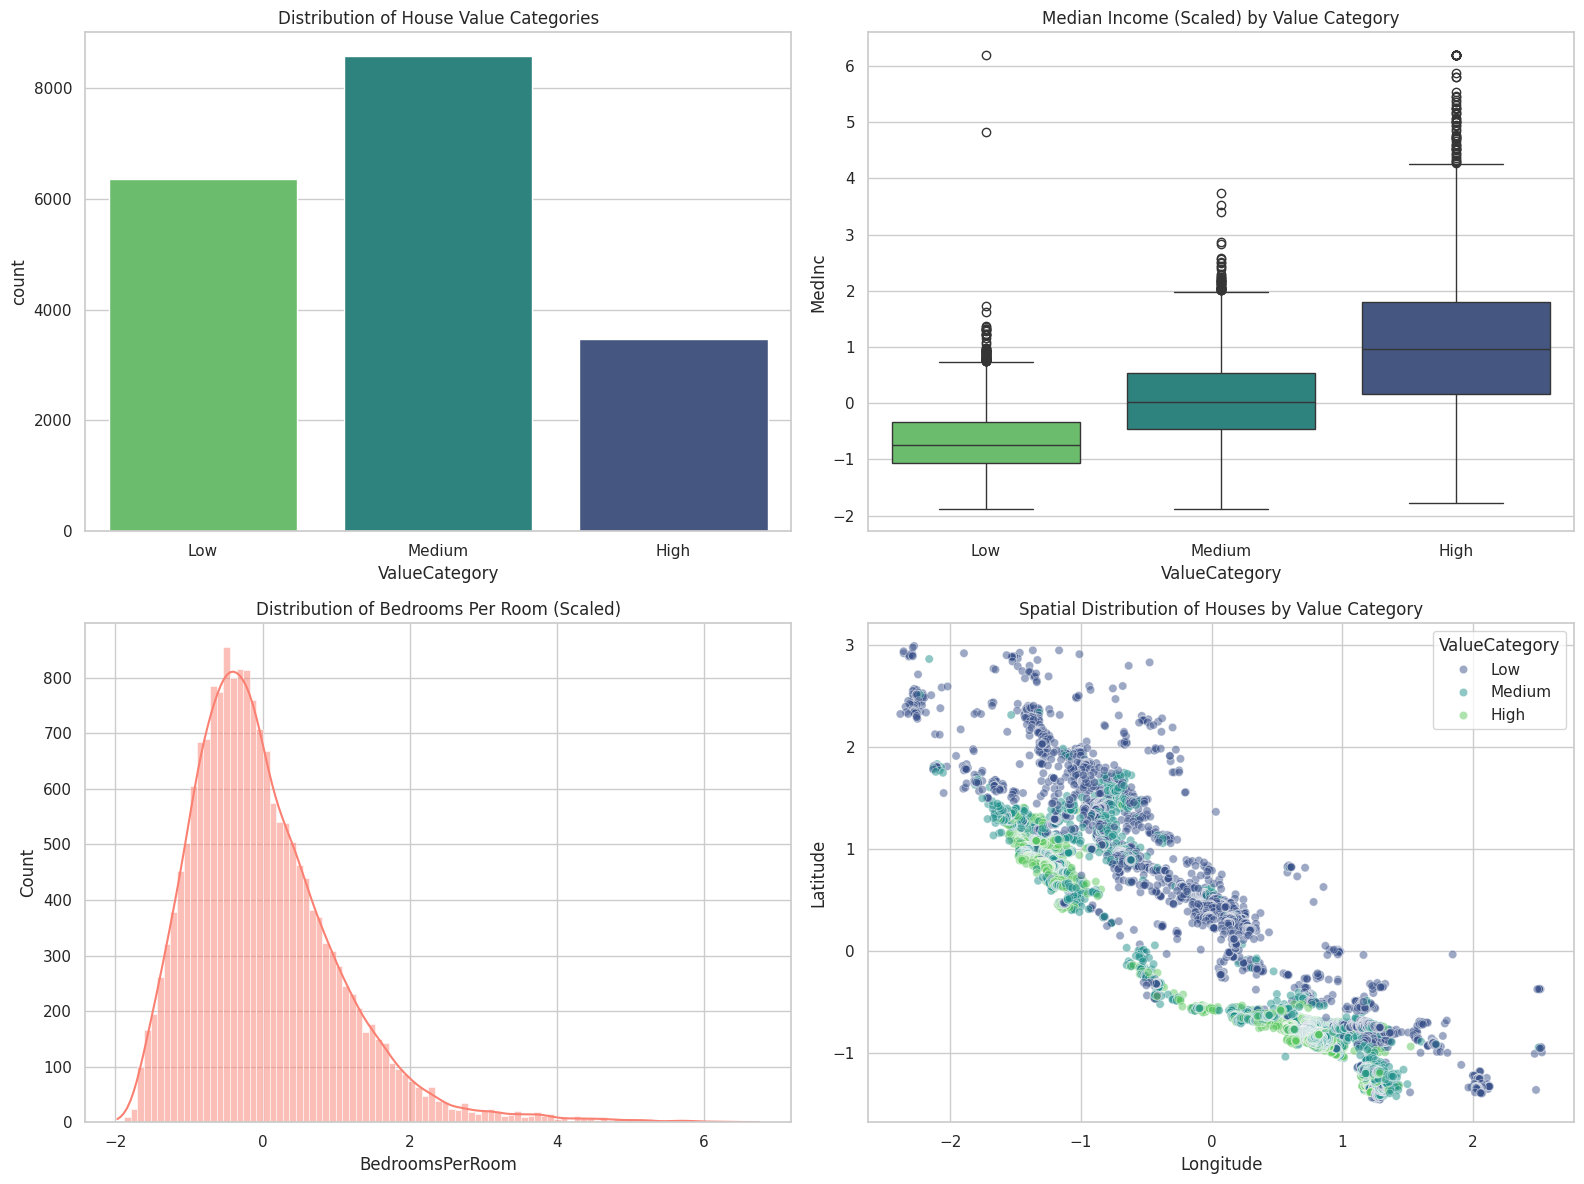

--- Descriptive Statistics for Features by Value Category ---
                 MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
ValueCategory                                                                  
High           1.094715  0.242665  0.627323  -0.079662   -0.129030 -0.526982   
Low           -0.669317 -0.073258 -0.258293   0.157043   -0.032807  0.230559   
Medium         0.054172 -0.043720 -0.061892  -0.084324    0.076489  0.041916   

               Latitude  Longitude  BedroomsPerRoom  
ValueCategory                                        
High          -0.091568  -0.137389        -0.454374  
Low            0.283467  -0.024666         0.198094  
Medium        -0.173312   0.073827         0.036659  


In [55]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(x='ValueCategory', hue='ValueCategory', data=df_transformed, ax=axes[0, 0], order=['Low', 'Medium', 'High'], palette='viridis', legend=False)
axes[0, 0].set_title('Distribution of House Value Categories')

sns.boxplot(x='ValueCategory', y='MedInc', hue='ValueCategory', data=df_transformed, ax=axes[0, 1], order=['Low', 'Medium', 'High'], palette='viridis', legend=False)
axes[0, 1].set_title('Median Income (Scaled) by Value Category')

sns.histplot(df_transformed['BedroomsPerRoom'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Bedrooms Per Room (Scaled)')

sns.scatterplot(x='Longitude', y='Latitude', hue='ValueCategory', data=df_transformed, ax=axes[1, 1], palette='viridis', alpha=0.5, hue_order=['Low', 'Medium', 'High'])
axes[1, 1].set_title('Spatial Distribution of Houses by Value Category')

plt.tight_layout()
plt.show()

print('--- Descriptive Statistics for Features by Value Category ---')
print(df_transformed.groupby('ValueCategory')[features_to_scale].mean())

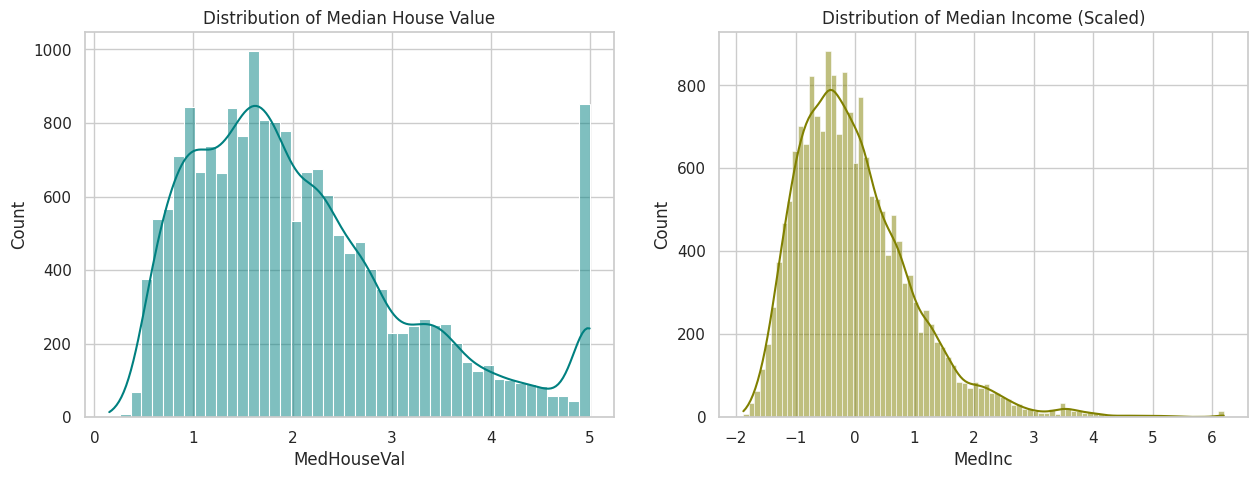

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_transformed['MedHouseVal'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Median House Value')

sns.histplot(df_transformed['MedInc'], kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribution of Median Income (Scaled)')

plt.show()

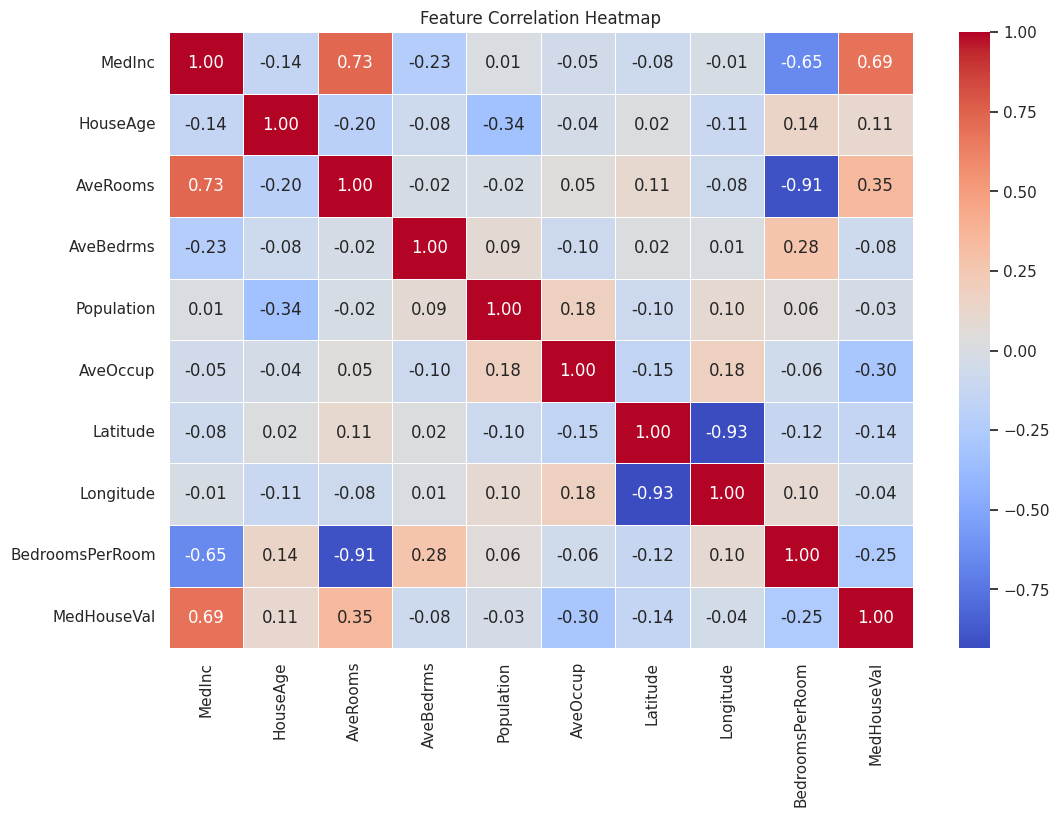

In [57]:
plt.figure(figsize=(12, 8))
corr_matrix = df_transformed[features_to_scale + ['MedHouseVal']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

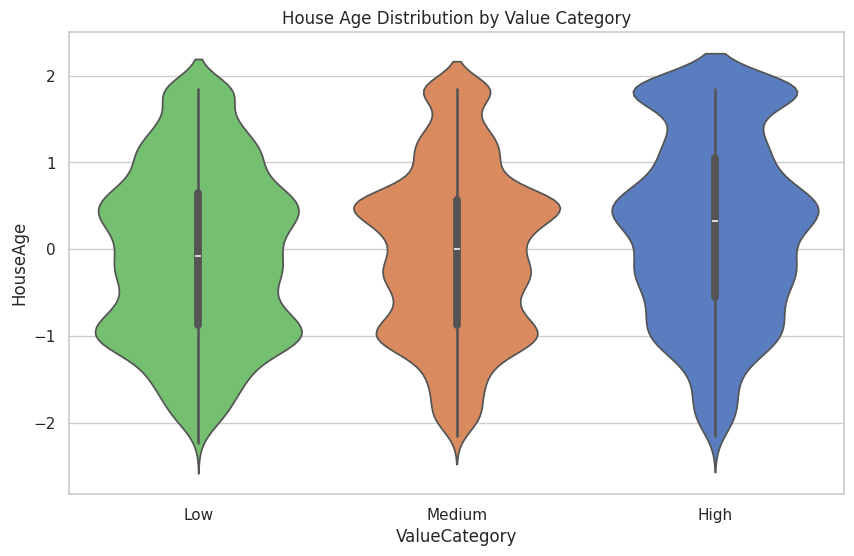

In [58]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='ValueCategory', y='HouseAge', hue='ValueCategory', data=df_transformed, palette='muted', order=['Low', 'Medium', 'High'], legend=False)
plt.title('House Age Distribution by Value Category')
plt.show()

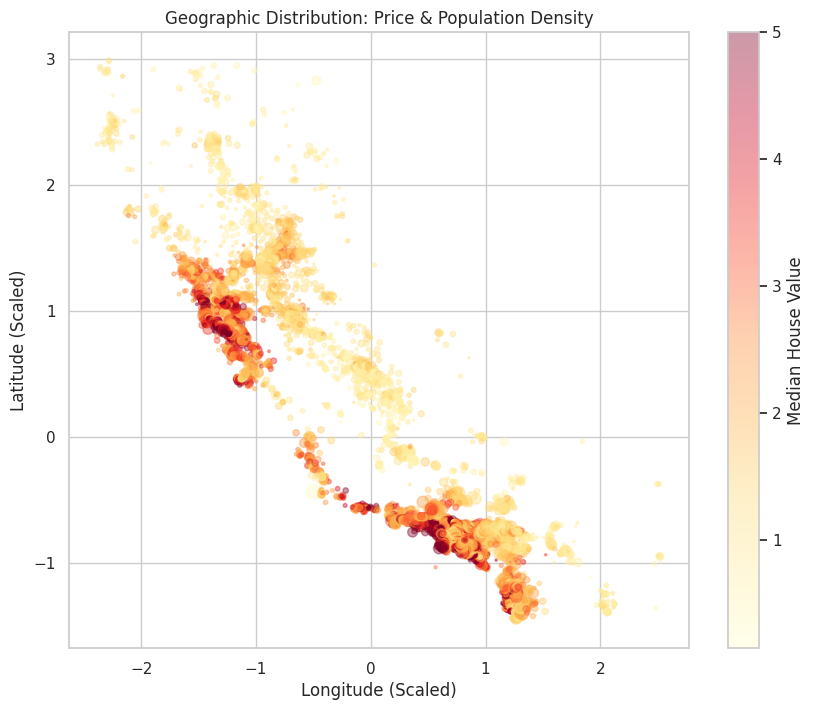

In [59]:
plt.figure(figsize=(10, 8))
# Clip population to ensure no negative sizes for the scatter plot
sizes = (df_transformed['Population'] - df_transformed['Population'].min() + 0.1) * 10
plt.scatter(df_transformed['Longitude'], df_transformed['Latitude'],
            c=df_transformed['MedHouseVal'], cmap='YlOrRd', alpha=0.4, s=sizes)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude (Scaled)')
plt.ylabel('Latitude (Scaled)')
plt.title('Geographic Distribution: Price & Population Density')
plt.show()